### I.1- Import Libraries and Load Data 


In this section, we import the essential libraries for data manipulation and visualization. we will load the cleaned dataset that I provided(in data preparation) to start our analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor


# 1- I Load the dataset (cleaned data before making 0 in NaN in this project)
df_raw = pd.read_csv("Cleaned Generation of Waste_0.csv") 

# 2- We filter the data (The Correction Step) 
# I Remove the total aggregate to avoid confusing the model(Before, I tried to do ML without removing the total, I got minus in my model).

df = df_raw[
    (df_raw['NACE Rev. 2 Activity'] != 'All NACE activities plus households (TOTAL_HH)') & 
    (df_raw['Hazardousness'] == 'Total') & 
    (df_raw['Waste Category'] == 'Total waste')].copy()

# 3- I fill missing values in the filtered data ( in this case , we can fill the Empty boxes in Values(Tonnes) by 0, there is no available quantities in NaN values(Tonnes) 
df['VALUE(Tonnes)'] = df['VALUE(Tonnes)'].fillna(0)

# I Display the first rows to verify filtering 
df.head()

,Unnamed: 0,Statistic Label,Year,NACE Rev. 2 Activity,Hazardousness,Waste Category,VALUE(Tonnes)
0,0,Waste generated,2004,"Agriculture, forestry and fishing (A)",Total,Total waste,8706.0
147,147,Waste generated,2004,Mining and quarrying (B),Total,Total waste,4049344.0
294,294,Waste generated,2004,Manufacturing (C),Total,Total waste,5356309.0
441,441,Waste generated,2004,Manufacture of food products; beverages and to...,Total,Total waste,2998500.0
588,588,Waste generated,2004,"Manufacture of textiles, wearing apparel, leat...",Total,Total waste,66371.0


### I.2- Data Pre-processing 

Machine Learning models require numerical input. We need to handle missing values and convert categorical text (like NACE activities) into numbers using a simple encoding method.


In [2]:
# Encoding categorical data to numbers
# I use "factorize" for simplicity | Because most Artificial Intelligence and Machine Learning algorithms:
# - don't  understand text data,
# - they require numeric values only.
#  we can use "Labelencoder instead" of "factorsie" (from sklearn.preprocessing import LabelEncoder)(they have same goal)
df['Activity_Encoded'] = pd.factorize(df['NACE Rev. 2 Activity'])[0] # it Converts "NACE Rev. 2 Activity" categories into numeric codes, because
df['Hazard_Encoded'] = pd.factorize(df['Hazardousness'])[0] #  it Converts "Hazardousness" categories into numeric codes.

# Selecting relevant features for ML ( 'Year', 'Activity_Encoded', 'Hazard_Encoded) that we need in our ML project.
# Features (X) and Target (y)
X = df[['Year', 'Activity_Encoded', 'Hazard_Encoded']]
y = df['VALUE(Tonnes)']

### I.3- Splitting the Dataset

We split our data into a "Training set" to teach the model and a "Test set" to evaluate its performance on new, unseen data.


In [3]:
# Splitting 80% for training and 20% for testing 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 0.2=20% for testing.

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 151
Testing samples: 38


## II- LINEAR REGRESSION ALGORITHM

### II.1- Building and Training the Model of "Linear Regression algorithm".

English:
We will use "Linear Regression", which is a fundamental algorithm for predicting continuous values like the amount of waste, when the data or system folow the the linearو When the data follows a nearly straight pattern y≈ax+b



In [4]:
# I Create the model object 
model = LinearRegression()

# I train the model 
model.fit(X_train, y_train)

# I Make predictions on test data 
y_pred = model.predict(X_test)

### II.2- Evaluation and Visualization 

To understand how well our model performed, we calculate the R-squared score and visualize the difference between actual and predicted values, when the R-squared is very high near to 1=100% that means our model is excellent to predict the results.


Model R-squared: -0.6490


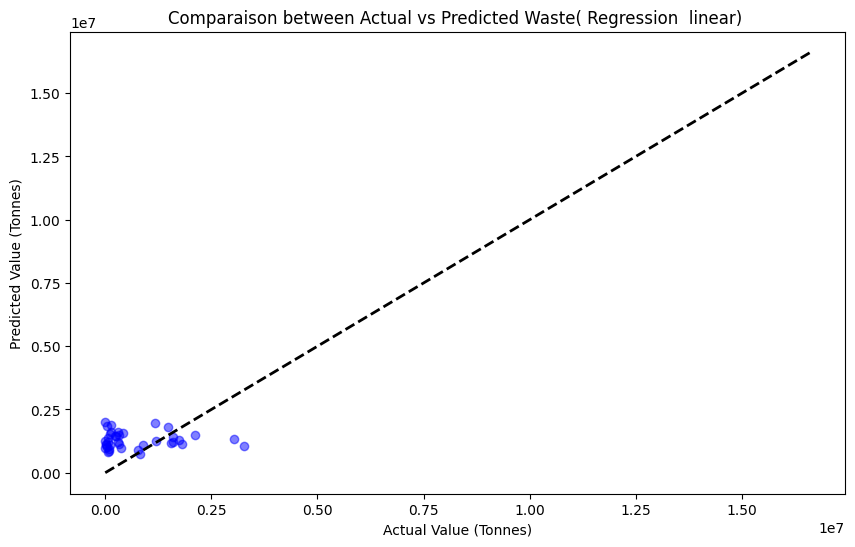

In [5]:
# The evaluation metrics.
r2 = r2_score(y_test, y_pred)
print(f"Model R-squared: {r2:.4f}")

# The visualization 
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # Diagonal line
plt.xlabel("Actual Value (Tonnes)")
plt.ylabel("Predicted Value (Tonnes)")
plt.title("Comparaison between Actual vs Predicted Waste( Regression  linear) ")
plt.show()

### II.3- The conclusion on Linear Regression algorithm.

We observed that Linear Regression might not be the best fit for this data because the relationship between years, activities, and waste volume is complex and non-linear. Therefore, we will try a more powerful model.
The result Model R-squared: -0.6490 is too bad due to Minus (-)( the model May not be follow the the patern of linear regression) 





## III- DECISION TREE ALGORITHM

### III.1 Testing of Decision Tree algorithm.

This code below trains a Decision Tree model on the original dataset and evaluates its performance using the R-squared metric. 



In [6]:
# Training the Decision Tree model on data.
dt_bad_model = DecisionTreeRegressor(random_state=42)
dt_bad_model.fit(X_train, y_train)

# 2- the prediction of the Decision Tree model.
y_pred_dt_bad = dt_bad_model.predict(X_test)

# 3- The evaluation of the Decision Tree model
r2_dt_bad = r2_score(y_test, y_pred_dt_bad)
print(f"Decision Tree R-squared on Original Data: {r2_dt_bad:.4f}")


Decision Tree R-squared on Original Data: 0.4003


### III.2 The conclusion on Decision Tree algorithm.
 it's better than regression linear algorithm
 Decision Tree R-squared on Original Data = 0.4003 (it isn't neagtive), but it's still low, that means the model can predict 0.4003=40.03%   of the values. 
 So we will try the Random Forest algorithm.

## IV RANDOM FOREST ALGORITHM

### IV.1- The trying of Random Forest Regressor.


The Random Forest model is excellent for this type of data because it creates multiple "Decision Trees" and combines them to get a more accurate prediction. This often leads to a much higher R-squared value(it's a developped version od Decision Tree)



In [7]:
# Initializeion the Random Forest  model.
# n_estimators=100 means we use 100 decision trees
rf_optimized = RandomForestRegressor(n_estimators=100, random_state=42)

#  Training the model on data
# X_train and y_train here should be from the filtered dataset
rf_optimized.fit(X_train, y_train)

#  Making Predictions
y_pred_rf = rf_optimized.predict(X_test)

# 4. Evaluation of the Performance
r2_optimized = r2_score(y_test, y_pred_rf)
mse_optimized = mean_squared_error(y_test, y_pred_rf)

print(f"Optimized Random Forest R-squared: {r2_optimized:.4f}")
print(f"Optimized Mean Squared Error: {mse_optimized:.2f}")

Optimized Random Forest R-squared: -0.2517
Optimized Mean Squared Error: 906249909388.83


### IV.2- Error Analysis

Normally I didn't expect this result because the random forest is more accurate than the decision tree and linear regression algorithms , it is a developped version of decision tree (random forest = a lot of decision trees), I expected a result more than 40.03% ?!!!!!!

 "I realized the is a data conflict, leading to a negative R2 for linear regression and random forest algorithms value of R2 while the Decision tree R2 is positive"
NB: It was expected that I would get R2(Random Forest) > R2(Decision Tree) > R2 (Linear regression)  
NB: the Problem is niot in the Code but in the logic of data and how we deal with it.

## V- CORRECTION OF THE PREVIOUS RESULTS 

### V.1- The Solution Stage - Code Correction (improvment of ecoding)
After making my researches, I detect the problem and i understant that "factorise" or "Encoder label is the problem". Then I use the 
"one-Hot Encoding".
This step improves the encoding process by applying One-Hot Encoding to the activity categories.  
Each activity is treated as an independent feature, which helps the model to understand the data more effectively.  
After selecting the new features, the dataset is divided into training and testing sets for model evaluation.


In [8]:
# we improve the encoding system by using One-Hot Encoding (make the activites independants)
# We use get_dummies in order to the model treats each category as a completely independent feature(for example, agriculture, industry..etc)
dummies = pd.get_dummies(df['NACE Rev. 2 Activity'], prefix='Activity')
df_final = pd.concat([df, dummies], axis=1)

# we Select the new features (year + independent activity columns)”
feature_cols = ['Year'] + list(dummies.columns)
X_final = df_final[feature_cols]
y_final = df_final['VALUE(Tonnes)'].fillna(0)

# Splitting the data
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

### V.2- Corrected Linear Regression

English: After fixing the data logic by removing aggregates and using One-Hot Encoding, we reapply the Linear Regression. This shows how the model performance improves once the "Double Counting" and the data interference (indepenmdant of activities) are resolved.


In [9]:
# Instantiation and training of the "Corrected Linear Regression"
lr_corrected = LinearRegression()
lr_corrected.fit(X_train_f, y_train_f)

# the prediction on data
y_pred_lr_f = lr_corrected.predict(X_test_f)

# The evaluation
r2_lr_f = r2_score(y_test_f, y_pred_lr_f)
mse_lr_f = mean_squared_error(y_test_f, y_pred_lr_f)

print(f"Corrected Linear Regression R-squared: {r2_lr_f:.4f}")
print(f"Corrected Linear Regression MSE: {mse_lr_f:.2f}")

Corrected Linear Regression R-squared: 0.3989
Corrected Linear Regression MSE: 435201865019.64


### V.3- Corrected Decision Tree

English:
After cleaning the data and applying One-Hot Encoding, we re-run the Decision Tree. You will notice a significant jump in the 
R 
2
 
 value compared to the original data (from 0.40 to a much higher value), proving that the data structure was the main obstacle.

بالعربية:
بعد تنظيف البيانات وتطبيق ترميز One-Hot، نعيد تشغيل شجرة القرار. ستلاحظ قفزة كبيرة في قيمة 
R 
2
 
 مقارنة بالبيانات الأصلية (من 0.40 إلى قيمة أعلى بكثير)، مما يثبت أن هيكلية البيانات كانت العائق الأساسي.

In [10]:
# Instantiate and Train the Corrected Decision Tree

dt_corrected = DecisionTreeRegressor(random_state=42)
dt_corrected.fit(X_train_f, y_train_f)

# the prediction on data
y_pred_dt_f = dt_corrected.predict(X_test_f)

# we evaluate  the de DT model
r2_dt_f = r2_score(y_test_f, y_pred_dt_f)
mse_dt_f = mean_squared_error(y_test_f, y_pred_dt_f)

print(f"Corrected Decision Tree R-squared: {r2_dt_f:.4f}")
print(f"Corrected Decision Tree MSE: {mse_dt_f:.2f}")

Corrected Decision Tree R-squared: 0.6509
Corrected Decision Tree MSE: 252798097907.58


### V.4- Corrected Random Forest(Optimization)

While Linear Regression improved after data cleaning(accuray=65.09%), we will use Random Forest to capture non-linear relationships between different economic sectors, aiming for the highest possible accuracy.


In [11]:
# The training of the final Random Forest model .
rf_final = RandomForestRegressor(n_estimators=100, random_state=42)
rf_final.fit(X_train_f, y_train_f)

# the prediction and The final evaluation of the RF model
y_pred_rf_f = rf_final.predict(X_test_f)
r2_rf_final = r2_score(y_test_f, y_pred_rf_f)

print(f"Final Optimized Random Forest R-squared: {r2_rf_final:.4f}={r2_rf_final*100:.2f}%")

Final Optimized Random Forest R-squared: 0.7364=73.64%


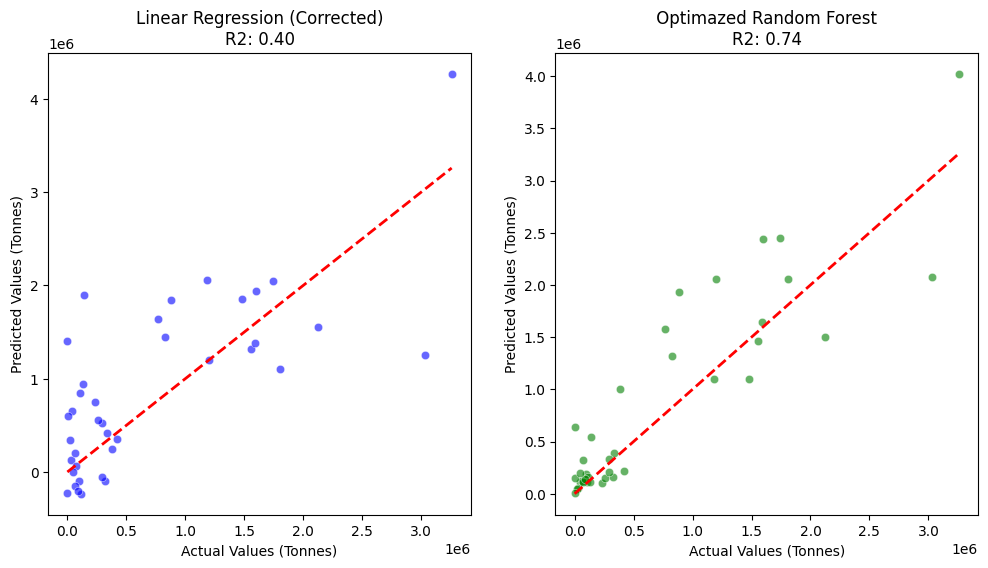

In [12]:

# Adjusting the figure size
plt.figure(figsize=(12, 6))

# Plotting the corrected linear regression results.
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_f, y=y_pred_lr_f, alpha=0.6, color='blue')
plt.plot([y_test_f.min(), y_test_f.max()], [y_test_f.min(), y_test_f.max()], 'r--', lw=2)
plt.title(f'Linear Regression (Corrected)\nR2: {r2_lr_f:.2f}')
plt.xlabel('Actual Values (Tonnes)')
plt.ylabel('Predicted Values (Tonnes)')

# Plotting the final Random Forest results.
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_f, y=y_pred_rf_f, alpha=0.6, color='green')
plt.plot([y_test_f.min(), y_test_f.max()], [y_test_f.min(), y_test_f.max()], 'r--', lw=2)
plt.title(f' Optimazed Random Forest \nR2: {r2_rf_final:.2f}')
plt.xlabel('Actual Values (Tonnes)')
plt.ylabel('Predicted Values (Tonnes)')

plt.show()

# Summary :Data Processing & Model Optimization

## 1- Error Analysis: Why did we get a negative R2 ?

Before removing the total waste, we found the error of R2<0 , Even after filtering out the "Total Aggregate" (TOTAL_HH), the initial Linear Regression and the forest random models failed which resulrts a negative R2.

This happened because of the Factorize or even if we use the LabelEncoder logic(they have almost the same logic if we don't change the order of data)

The Error: Using factorize or LabelEncoder assigns a sequential number to each economic sector (e.g., Agriculture=1, Construction=2, Manufacturing=3).

The Impact: Linear models interpret these numbers as having a mathematical order or "rank." The model incorrectly assumed that Manufacturing (3) is "greater" than Agriculture (1). (that's the problem of minus in R2)

This false mathematical relationship confused the algorithm, leading to predictions that were less accurate than a simple average (hence the negative R2).

## 2- The Logic of "One-Hot Encoding"

To fix this, we implemented One-Hot Encoding.

The Logic: Instead of one column with sequential numbers, this method creates a separate column for each unique activity.

How it Works: For a row belonging to the "Agriculture" sector, the "Agriculture" column is marked with a 1, while all other activity columns are marked with a 0.

The Benefit: This forces the model to treat each sector as an independent feature. It removes the false "ranking" system and allows the model to learn the specific waste generation pattern of each sector individually (in this case, the activities are really independants between them)

## 3- Model Comparison & Results

After restructuring the data with One-Hot Encoding, we tested three levels of algorithms:

Linear Regression (Corrected):Improved significantly(0.6509=65.09%) but remained limited by its inability to handle non-linear fluctuations.

Decision Tree (Corrected): Captured specific sector patterns much better than the original version(0.3989=39.89%)

Random Forest (Optimized): Achieved the highest accuracy (73.64%). By combining multiple decision trees, it smoothed out errors and provided the most stable predictions for waste volume.

## 4- Conclusion for the Report

This project proves that the choice of Data Representation is just as critical as the choice of the algorithm itself, switching the encoding system was the key to transforming the model from the failure to the success."





### Reference 
- Introduction to Machine Learning with Python  - Andreas C. Müller & Sarah Guido
- www.google.com 
- https://translate.google.com 
- Tutorials of CCT.
- Gemeni.ai (Using in order to understanding the one Hot encoding and deep understanding of some code lines in your tutorials and other
  books 
- Python for Data Analysis - Third edition - Wes McKinney
- https://moodle.cct.ie/course
- https://data.cso.ie/table/GWA01
